In [1]:
# Preprocesamiento de los datos
import tensorflow as tf

# Cargamos el dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [2]:
# Exploramos las formas y dimensiones
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)
print("Tipo de dato:", x_train.dtype)
print("Mín / Máx píxel:", x_train.min(), x_train.max())

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)
Tipo de dato: uint8
Mín / Máx píxel: 0 255


In [4]:
# Revisamos qué tipo de prenda representa cada número de 0 a 9
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
import numpy as np
print("Etiquetas únicas:", np.unique(y_train))
for c in np.unique(y_train):
    print(c, "→", class_names[c])

Etiquetas únicas: [0 1 2 3 4 5 6 7 8 9]
0 → T-shirt/top
1 → Trouser
2 → Pullover
3 → Dress
4 → Coat
5 → Sandal
6 → Shirt
7 → Sneaker
8 → Bag
9 → Ankle boot


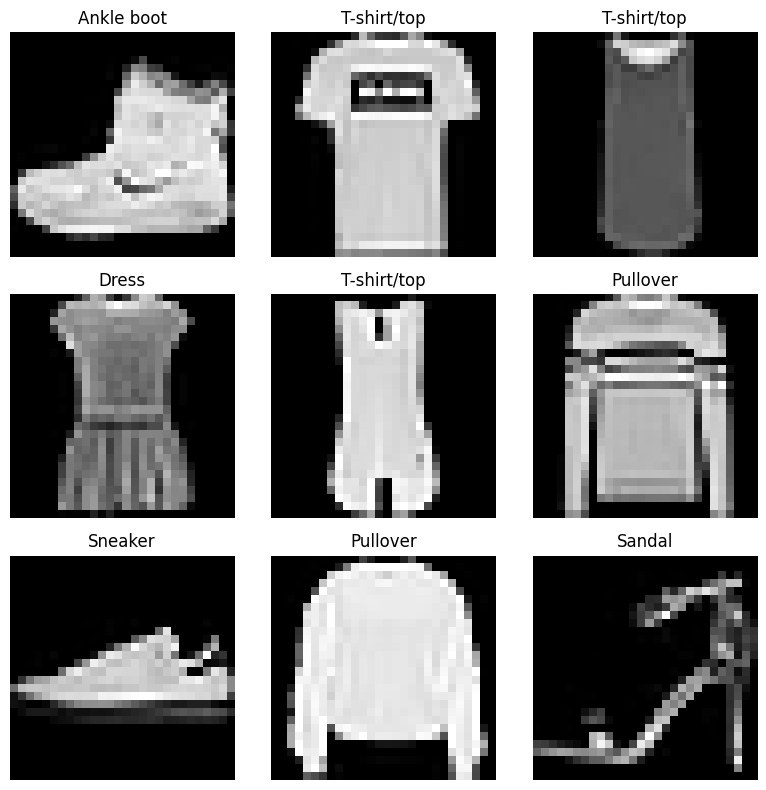

In [5]:
# Revisamos algunos ejemplos de imágenes
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

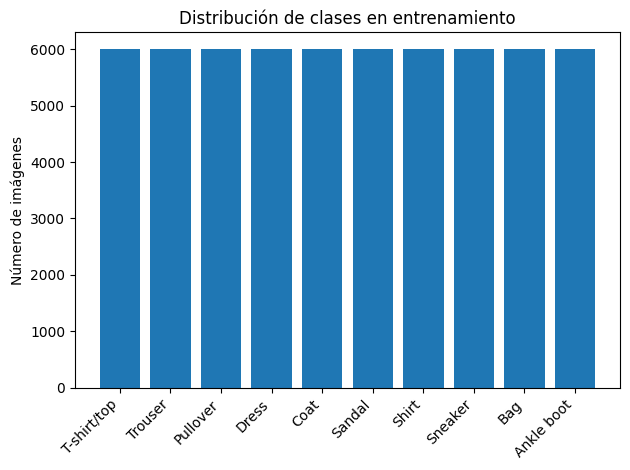

In [6]:
# Revisamos la distribución de clases por medio de un diagrama
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45, ha='right')
plt.ylabel("Número de imágenes")
plt.title("Distribución de clases en entrenamiento")
plt.tight_layout()
plt.show()

In [7]:
# Hacemos una normalización de píxeles antes de entrenar las redes
# Convertir a float32 y normalizar a [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Rango después de normalizar: ",
      x_train.min(), x_train.max())

Rango después de normalizar:  0.0 1.0


In [8]:
# Para red neuronal básica (MLP): aplanar 28*28 = 784
x_train_mlp = x_train.reshape(-1, 28*28)
x_test_mlp  = x_test.reshape(-1, 28*28)

# Para CNN: agregar canal (grayscale = 1)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)

print("Shape x_train_mlp:", x_train_mlp.shape)
print("Shape x_train_cnn:", x_train_cnn.shape)

Shape x_train_mlp: (60000, 784)
Shape x_train_cnn: (60000, 28, 28, 1)
